# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  🧠 Deep Learning Training Pipeline — CIC-IDS-2018                        ║
# ║  Phase 2: Optimization — PSO Feature Selection                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
# Adaptation from PCA → PSO (Particle Swarm Optimization)
# ────────────────────────────────────────────────────────
# PCA : StandardScaler → PCA(57 → 30 components)    [unsupervised, linear projection]
# PSO : StandardScaler → PSO binary feature mask    [metaheuristic, searches subset space]
#
# How PSO replaces PCA here:
#   • Each PARTICLE = a binary vector of length 57 (1 = keep feature, 0 = drop)
#   • VELOCITY     = continuous vector → sigmoid → probability of bit being 1
#   • FITNESS      = balanced_accuracy of a fast proxy classifier (LogisticRegression)
#     evaluated on a small validation fold (NO DL training during PSO — too slow)
#   • SWARM evolves over PSO_ITERATIONS to maximize fitness
#   • Best binary mask → applied to StandardScaler-transformed data → fed to CNN / LSTM
#
# Key principle preserved (same as PCA notebook):
#   • Fit scaler + find mask on TRAIN only → no data leakage
#   • Same models (1D-CNN, LSTM), same callbacks, same metrics
#   • Scaler + mask saved (pkl) per model for inference
#   • PSO targets N_FEATURES_TARGET ≈ 30 selected features (same dim as N_COMPONENTS=30)


# ─────────────────────────────────────────────────────────────────────────────
# 1. Import Libraries
# ─────────────────────────────────────────────────────────────────────────────


In [1]:
import pandas as pd
import numpy as np
import time
import pickle
import warnings
import os
warnings.filterwarnings('ignore')
 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, BatchNormalization,
    Dropout, Dense, Flatten, LSTM, Reshape
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, balanced_accuracy_score
)
 
import matplotlib.pyplot as plt
import seaborn as sns
 
# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)
 
# ── GPU Configuration ─────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f'✅ GPU enabled: {len(gpus)} Physical, {len(logical_gpus)} Logical GPU(s)')
    except RuntimeError as e:
        print(f'⚠️  GPU config error: {e}')
else:
    print('⚠️  No GPU detected — running on CPU.')
 
print()
print('=' * 80)
print('🧠 DEEP LEARNING TRAINING — CIC-IDS-2018 | PSO FEATURE SELECTION')
print('=' * 80)
print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print(f'GPU devices: {gpus}')


⚠️  No GPU detected — running on CPU.

🧠 DEEP LEARNING TRAINING — CIC-IDS-2018 | PSO FEATURE SELECTION
TensorFlow : 2.21.0
Keras      : 3.13.2
GPU devices: []


# ─────────────────────────────────────────────────────────────────────────────
# 2. Configuration
# ─────────────────────────────────────────────────────────────────────────────


In [2]:
INPUT_FILE     = 'archive/full_df_binary_labels.csv'
BASE_MODEL_DIR = 'trained_models/dl_optimized/pso/'
TEST_SIZE      = 0.2
RANDOM_STATE   = 42
SAVE_MODELS    = True
 
# ── PSO configuration ─────────────────────────────────────────────────────────
# These replace N_COMPONENTS=30 in PCA — PSO discovers the optimal feature subset.
N_FEATURES_TARGET = 30     # soft target: penalize mask with too many/few features
PSO_N_PARTICLES   = 30     # swarm size (more → better exploration, slower)
PSO_ITERATIONS    = 40     # iterations (more → better convergence, slower)
PSO_W             = 0.7    # inertia weight (momentum of velocity update)
PSO_C1            = 1.5    # cognitive coefficient (attraction to personal best)
PSO_C2            = 1.5    # social coefficient   (attraction to global best)
PSO_V_MAX         = 4.0    # velocity clamp (avoids bit saturation)
PSO_SAMPLE_SIZE   = 20_000 # rows for proxy fitness evaluation (fast LR, not DL)
PSO_PROXY_C       = 0.1    # LogisticRegression regularization strength
# Sparsity penalty: penalizes masks that deviate from N_FEATURES_TARGET
# fitness_penalized = fitness - ALPHA * |n_selected - N_FEATURES_TARGET| / n_total
PSO_ALPHA         = 0.01
 
# ── Training hyperparameters (identical to PCA notebook) ─────────────────────
BATCH_SIZE       = 256
EPOCHS           = 20
VALIDATION_SPLIT = 0.1
PATIENCE         = 10
 
# ── Per-model sample sizes ────────────────────────────────────────────────────
MODEL_SAMPLE_SIZES = {
    'CNN' : 10_000_000,
    'LSTM': 200_000,
}
 
os.makedirs(BASE_MODEL_DIR, exist_ok=True)
 
print('✅ Configuration set')
print(f'   PSO particles        : {PSO_N_PARTICLES}')
print(f'   PSO iterations       : {PSO_ITERATIONS}')
print(f'   PSO inertia (w)      : {PSO_W}')
print(f'   PSO cognitive (c1)   : {PSO_C1}')
print(f'   PSO social    (c2)   : {PSO_C2}')
print(f'   PSO vmax             : {PSO_V_MAX}')
print(f'   PSO proxy sample     : {PSO_SAMPLE_SIZE:,}')
print(f'   N_FEATURES_TARGET    : {N_FEATURES_TARGET}  (soft, analogous to N_COMPONENTS=30)')
print(f'   Batch size           : {BATCH_SIZE}')
print(f'   Max epochs           : {EPOCHS}')
print(f'   Validation split     : {VALIDATION_SPLIT}')
print(f'   EarlyStopping pat.   : {PATIENCE}')
print(f'   Output directory     : {BASE_MODEL_DIR}')


✅ Configuration set
   PSO particles        : 30
   PSO iterations       : 40
   PSO inertia (w)      : 0.7
   PSO cognitive (c1)   : 1.5
   PSO social    (c2)   : 1.5
   PSO vmax             : 4.0
   PSO proxy sample     : 20,000
   N_FEATURES_TARGET    : 30  (soft, analogous to N_COMPONENTS=30)
   Batch size           : 256
   Max epochs           : 20
   Validation split     : 0.1
   EarlyStopping pat.   : 10
   Output directory     : trained_models/dl_optimized/pso/


# ─────────────────────────────────────────────────────────────────────────────
# 3. Load Dataset
# ─────────────────────────────────────────────────────────────────────────────


In [3]:
CHUNK_SIZE = 100_000
chunks, total = [], 0
 
print(f'\n📂 Loading data from: {INPUT_FILE}')
print('⏳ Reading in chunks...\n')
 
for i, chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)):
    chunks.append(chunk)
    total += len(chunk)
    if (i + 1) % 20 == 0:
        print(f'   Chunk {i+1:>4}: {len(chunk):,} rows | Total: {total:,}')
 
df_full = pd.concat(chunks, ignore_index=True)
del chunks
df_full = df_full.drop(columns=['Label'], errors='ignore')
 
print(f'\n✅ Dataset loaded')
print(f'   Rows   : {len(df_full):,}')
print(f'   Columns: {len(df_full.columns)}')
print(df_full['Label_Binary'].value_counts())



📂 Loading data from: archive/full_df_binary_labels.csv
⏳ Reading in chunks...

   Chunk   20: 100,000 rows | Total: 2,000,000
   Chunk   40: 100,000 rows | Total: 4,000,000
   Chunk   60: 100,000 rows | Total: 6,000,000
   Chunk   80: 100,000 rows | Total: 8,000,000
   Chunk  100: 100,000 rows | Total: 10,000,000
   Chunk  120: 100,000 rows | Total: 12,000,000
   Chunk  140: 100,000 rows | Total: 14,000,000
   Chunk  160: 100,000 rows | Total: 16,000,000

✅ Dataset loaded
   Rows   : 16,232,943
   Columns: 58
Label_Binary
0    13484708
1     2748235
Name: count, dtype: int64


# ─────────────────────────────────────────────────────────────────────────────
# 4. Prepare Features and Target
# ─────────────────────────────────────────────────────────────────────────────


In [4]:
label_columns   = ['Label', 'Label_Binary']
existing_labels = [c for c in label_columns if c in df_full.columns]
 
X_full        = df_full.drop(columns=existing_labels).select_dtypes(include=[np.number])
y_full        = df_full['Label_Binary']
feature_names = X_full.columns.tolist()
N_FEATURES    = X_full.shape[1]
del df_full
 
print(f'✅ Features (X): {X_full.shape}')
print(f'✅ Target   (y): {y_full.shape}')
print(f'\n📊 Original features : {N_FEATURES}')
print(f'📊 PSO target        : ~{N_FEATURES_TARGET} features selected')
 
print(f'\n📊 Class Distribution:')
vc = y_full.value_counts()
for k, v in vc.items():
    label = 'Benign' if k == 0 else 'Attack'
    print(f'   {label} ({k}): {v:>10,}  ({v/len(y_full)*100:.2f}%)')


✅ Features (X): (16232943, 57)
✅ Target   (y): (16232943,)

📊 Original features : 57
📊 PSO target        : ~30 features selected

📊 Class Distribution:
   Benign (0): 13,484,708  (83.07%)
   Attack (1):  2,748,235  (16.93%)


# ─────────────────────────────────────────────────────────────────────────────
# 5. PSO Feature Selection  
# ─────────────────────────────────────────────────────────────────────────────


In [5]:
def _sigmoid(v):
    """Numerically stable sigmoid."""
    return 1.0 / (1.0 + np.exp(-np.clip(v, -500, 500)))
 
 
def _fitness(mask, X_tr, X_val, y_tr, y_val, n_features_target, alpha, proxy_C):
    """
    Evaluate a binary feature mask using a fast proxy classifier (Logistic Regression).
    Returns penalized balanced accuracy.
 
    fitness = balanced_accuracy(LR on selected features)
              - alpha * |n_selected - n_features_target| / n_total
 
    This replaces PCA's implicit dimensionality selection with an explicit
    supervised search guided by classification performance.
    """
    selected = np.where(mask == 1)[0]
    if len(selected) == 0:
        return 0.0   # empty mask → zero fitness
 
    X_tr_sel  = X_tr[:, selected]
    X_val_sel = X_val[:, selected]
 
    lr = LogisticRegression(
        C=proxy_C, max_iter=200,
        solver='saga', n_jobs=-1,
        class_weight='balanced',
        random_state=42
    )
    lr.fit(X_tr_sel, y_tr)
    y_pred = lr.predict(X_val_sel)
 
    bal_acc = balanced_accuracy_score(y_val, y_pred)
    # Sparsity penalty: keep feature count close to target
    penalty = alpha * abs(len(selected) - n_features_target) / len(mask)
    return float(bal_acc - penalty)
 
 
def run_pso(X_train_scaled, y_train, n_features, n_particles, n_iterations,
            w, c1, c2, v_max, n_features_target, alpha, proxy_C,
            pso_sample_size, random_state):
    """
    Binary PSO for feature selection.
    Returns: best_mask (np.ndarray, shape=(n_features,), dtype=int)
             fitness_history (list of best fitness per iteration)
    """
    rng = np.random.RandomState(random_state)
    print(f'\n🐝 PSO: {n_particles} particles × {n_iterations} iterations')
    print(f'   Proxy fitness: LogisticRegression on {pso_sample_size:,}-row subsample')
 
    # ── Proxy dataset (small — PSO fitness is expensive if we use full data) ──
    idx = rng.choice(len(X_train_scaled), size=min(pso_sample_size, len(X_train_scaled)),
                     replace=False)
    X_pso = X_train_scaled[idx]
    y_pso = y_train.iloc[idx] if hasattr(y_train, 'iloc') else y_train[idx]
 
    X_pso_tr, X_pso_val, y_pso_tr, y_pso_val = train_test_split(
        X_pso, y_pso, test_size=0.2, random_state=random_state,
        stratify=y_pso
    )
 
    # ── Initialise swarm ──────────────────────────────────────────────────────
    # Positions: random binary, biased toward ~N_FEATURES_TARGET bits set
    prob_init = n_features_target / n_features
    positions  = (rng.rand(n_particles, n_features) < prob_init).astype(float)
    velocities = rng.uniform(-1.0, 1.0, (n_particles, n_features))
 
    # Evaluate initial fitness
    fitnesses = np.array([
        _fitness(positions[i].astype(int), X_pso_tr, X_pso_val,
                 y_pso_tr, y_pso_val, n_features_target, alpha, proxy_C)
        for i in range(n_particles)
    ])
 
    pbest_pos = positions.copy()
    pbest_fit = fitnesses.copy()
    gbest_idx = np.argmax(pbest_fit)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]
 
    fitness_history = [gbest_fit]
    n_selected_history = [int(gbest_pos.sum())]
 
    print(f'   Init  → gbest fitness={gbest_fit:.4f}, '
          f'n_selected={int(gbest_pos.sum())}')
 
    for it in range(n_iterations):
        r1 = rng.rand(n_particles, n_features)
        r2 = rng.rand(n_particles, n_features)
 
        # Velocity update  (standard PSO equation)
        velocities = (w * velocities
                      + c1 * r1 * (pbest_pos - positions)
                      + c2 * r2 * (gbest_pos - positions))
        velocities = np.clip(velocities, -v_max, v_max)
 
        # Binary transfer function: sigmoid → stochastic binarisation
        probs     = _sigmoid(velocities)
        positions = (rng.rand(n_particles, n_features) < probs).astype(float)
 
        # Evaluate new positions
        fitnesses = np.array([
            _fitness(positions[i].astype(int), X_pso_tr, X_pso_val,
                     y_pso_tr, y_pso_val, n_features_target, alpha, proxy_C)
            for i in range(n_particles)
        ])
 
        # Update personal bests
        improved = fitnesses > pbest_fit
        pbest_pos[improved] = positions[improved].copy()
        pbest_fit[improved] = fitnesses[improved]
 
        # Update global best
        curr_best_idx = np.argmax(pbest_fit)
        if pbest_fit[curr_best_idx] > gbest_fit:
            gbest_pos = pbest_pos[curr_best_idx].copy()
            gbest_fit = pbest_fit[curr_best_idx]
 
        fitness_history.append(gbest_fit)
        n_selected_history.append(int(gbest_pos.sum()))
 
        if (it + 1) % 5 == 0 or it == 0:
            print(f'   Iter {it+1:>3}/{n_iterations} → '
                  f'gbest fitness={gbest_fit:.4f}, '
                  f'n_selected={int(gbest_pos.sum())}')
 
    best_mask = gbest_pos.astype(int)
    print(f'\n✅ PSO converged')
    print(f'   Best fitness     : {gbest_fit:.4f}')
    print(f'   Features selected: {best_mask.sum()}  (target was {n_features_target})')
    return best_mask, fitness_history, n_selected_history
 
 
def apply_pso_pipeline(X_train, X_test, y_train,
                       n_features, n_particles, n_iterations,
                       w, c1, c2, v_max, n_features_target, alpha,
                       proxy_C, pso_sample_size, random_state):
    """
    StandardScaler → PSO binary mask.
    Fit on train only — no data leakage.
    Replaces apply_pca_pipeline from the PCA notebook.
 
    Returns: X_train_pso, X_test_pso, scaler, best_mask, fitness_history
    """
    # Step 1: scale (same as PCA pipeline)
    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
 
    # Step 2: PSO search for optimal binary mask (replaces pca.fit_transform)
    best_mask, fitness_history, n_sel_history = run_pso(
        X_train_scaled, y_train,
        n_features, n_particles, n_iterations,
        w, c1, c2, v_max, n_features_target, alpha,
        proxy_C, pso_sample_size, random_state
    )
 
    selected_indices = np.where(best_mask == 1)[0]
 
    # Step 3: apply mask (replaces pca.transform)
    X_train_pso = X_train_scaled[:, selected_indices]
    X_test_pso  = X_test_scaled[:, selected_indices]
 
    print(f'\n   Original dims  : {X_train.shape[1]}')
    print(f'   Selected dims  : {X_train_pso.shape[1]}  (PSO mask)')
    print(f'   Removed        : {X_train.shape[1] - X_train_pso.shape[1]}')
    selected_names = [feature_names[i] for i in selected_indices]
    print(f'   Selected features (first 10): {selected_names[:10]}')
 
    return X_train_pso, X_test_pso, scaler, best_mask, fitness_history, n_sel_history
 
 
print('\n✅ PSO functions defined')



✅ PSO functions defined


# ─────────────────────────────────────────────────────────────────────────────
# 6. Helper: sample + split
# ─────────────────────────────────────────────────────────────────────────────


In [6]:
def get_model_data(X_full, y_full, model_name, sample_size,
                   test_size, random_state):
    if sample_size is None or sample_size >= len(X_full):
        if sample_size is not None:
            print(f'   ⚠️  Requested {sample_size:,} rows but only '
                  f'{len(X_full):,} available — using full dataset')
        X, y = X_full, y_full
        print(f'   📊 Using full dataset: {len(X):,} rows')
    else:
        print(f'   📊 Sampling {sample_size:,} rows from {len(X_full):,} (stratified)')
        X, _, y, _ = train_test_split(
            X_full, y_full,
            train_size=sample_size,
            random_state=random_state,
            stratify=y_full
        )
 
    print(f'\n   📊 Class distribution in sample:')
    for k, v in y.value_counts().items():
        label = 'Benign' if k == 0 else 'Attack'
        print(f'      {label} ({k}): {v:>10,}  ({v/len(y)*100:.2f}%)')
 
    print(f'\n   ✂️  Splitting train/test ({test_size*100:.0f}% test)...')
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size,
        random_state=random_state, stratify=y
    )
    print(f'   ✅ Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
    return X_train, X_test, y_train, y_test
 
print('✅ Helper function defined')


✅ Helper function defined


# ─────────────────────────────────────────────────────────────────────────────
# 7. Model Architectures  
# ─────────────────────────────────────────────────────────────────────────────

In [7]:
def build_cnn_model(n_features):
    model = Sequential([
        Reshape((n_features, 1), input_shape=(n_features,)),
        Conv1D(64,  kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model
 
 
def build_lstm_model(n_features):
    model = Sequential([
        Reshape((n_features, 1), input_shape=(n_features,)),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        BatchNormalization(),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model
 
 
MODEL_BUILDERS = {'CNN': build_cnn_model, 'LSTM': build_lstm_model}
print(f'✅ Defined {len(MODEL_BUILDERS)} model builders: {list(MODEL_BUILDERS.keys())}')


✅ Defined 2 model builders: ['CNN', 'LSTM']


# ─────────────────────────────────────────────────────────────────────────────
# 8. Train All Models
# ─────────────────────────────────────────────────────────────────────────────


In [8]:
results          = {}
histories        = {}
pso_masks        = {}
pso_fit_histories = {}
 
for model_name, model_builder in MODEL_BUILDERS.items():
    print('\n' + '=' * 80)
    print(f'🚀 TRAINING: {model_name} WITH PSO FEATURE SELECTION')
    print('=' * 80)
 
    model_dir = os.path.join(BASE_MODEL_DIR, model_name.lower())
    os.makedirs(model_dir, exist_ok=True)
    print(f'📁 Model directory: {model_dir}')
 
    sample_size = MODEL_SAMPLE_SIZES.get(model_name)
 
    # ── Prepare raw data ──────────────────────────────────────────────────
    print(f'\n📂 Preparing data for {model_name}...')
    X_train_raw, X_test_raw, y_train, y_test = get_model_data(
        X_full, y_full, model_name, sample_size, TEST_SIZE, RANDOM_STATE
    )
 
    # ── PSO feature selection (replaces apply_pca_pipeline) ───────────────
    print(f'\n🐝 Running PSO feature selection (fit on train only — no leakage)...')
    t_pso_start = time.time()
    X_train_pso, X_test_pso, scaler, best_mask, fit_hist, nsel_hist = apply_pso_pipeline(
        X_train_raw, X_test_raw, y_train,
        N_FEATURES, PSO_N_PARTICLES, PSO_ITERATIONS,
        PSO_W, PSO_C1, PSO_C2, PSO_V_MAX,
        N_FEATURES_TARGET, PSO_ALPHA,
        PSO_PROXY_C, PSO_SAMPLE_SIZE, RANDOM_STATE
    )
    pso_time = time.time() - t_pso_start
    n_selected = int(best_mask.sum())
    pso_masks[model_name]        = best_mask
    pso_fit_histories[model_name] = (fit_hist, nsel_hist)
    print(f'   PSO completed in {pso_time:.2f}s ({pso_time/60:.2f} min)')
 
    # ── Save transformers ─────────────────────────────────────────────────
    if SAVE_MODELS:
        with open(os.path.join(model_dir, 'scaler.pkl'), 'wb') as f:
            pickle.dump(scaler, f)
        with open(os.path.join(model_dir, 'pso_mask.pkl'), 'wb') as f:
            pickle.dump({'mask': best_mask,
                         'selected_indices': np.where(best_mask == 1)[0],
                         'selected_features': [feature_names[i] for i in np.where(best_mask == 1)[0]]
                         }, f)
        print(f'   💾 Scaler & PSO mask saved')
 
    # ── Build model (input dim = n_selected from PSO) ─────────────────────
    print(f'\n🔨 Building {model_name} model (input: {n_selected} PSO-selected features)...')
    model = model_builder(n_selected)
    model.summary()
 
    # ── Callbacks ─────────────────────────────────────────────────────────
    best_model_path = os.path.join(model_dir, 'best_model.keras')
    cb_list = [
        EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=max(2, PATIENCE // 3),
            min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            filepath=best_model_path,
            monitor='val_loss', save_best_only=True, verbose=1
        )
    ]
 
    # ── Train ─────────────────────────────────────────────────────────────
    print(f'\n⏱️  Training {model_name} with PSO-selected features...')
    start_time = time.time()
 
    history = model.fit(
        X_train_pso, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VALIDATION_SPLIT,
        callbacks=cb_list,
        verbose=1
    )
 
    train_time = time.time() - start_time
    print(f'\n✅ Training completed in {train_time:.2f}s ({train_time/60:.2f} min)')
 
    # ── Evaluate ──────────────────────────────────────────────────────────
    print(f'\n🔮 Evaluating on test set...')
    start_eval  = time.time()
    y_pred_prob = model.predict(X_test_pso, batch_size=BATCH_SIZE, verbose=0)
    y_pred      = (y_pred_prob > 0.5).astype(int).flatten()
    pred_time   = time.time() - start_eval
    print(f'✅ Predictions completed in {pred_time:.2f}s')
 
    # ── Compute metrics ───────────────────────────────────────────────────
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
 
    accuracy         = accuracy_score(y_test, y_pred)
    f1_macro         = f1_score(y_test, y_pred, average='macro',  zero_division=0)
    bal_acc          = balanced_accuracy_score(y_test, y_pred)
    benign_recall    = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    attack_recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    benign_precision = TN / (TN + FN) if (TN + FN) > 0 else 0.0
    attack_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
 
    print(f'\n📊 RESULTS WITH PSO:')
    print(f'   Balanced Accuracy    : {bal_acc:.4f}  ← primary metric')
    print(f'   F1 Macro             : {f1_macro:.4f}')
    print(f'   Benign Recall        : {benign_recall:.4f}')
    print(f'   Attack Recall        : {attack_recall:.4f}')
    print(f'   Benign Precision     : {benign_precision:.4f}')
    print(f'   Attack Precision     : {attack_precision:.4f}')
    print(f'   Plain Accuracy       : {accuracy:.4f}  ⚠️  (misleading on imbalanced data)')
    print(f'   PSO best fitness     : {fit_hist[-1]:.4f}')
    print(f'   Features selected    : {n_selected}  (target was {N_FEATURES_TARGET})')
 
    print(f'\n🕐 TIME:')
    print(f'   PSO search: {pso_time:.2f}s ({pso_time/60:.2f} min)')
    print(f'   Train     : {train_time:.2f}s ({train_time/60:.2f} min)')
    print(f'   Eval      : {pred_time:.2f}s')
 
    print(f'\n🎯 Confusion Matrix:')
    print(cm)
    print(f'   TN={TN:,}  FP={FP:,}  FN={FN:,}  TP={TP:,}')
 
    print(f'\n📋 Classification Report:')
    print(classification_report(y_test, y_pred,
                                target_names=['Benign', 'Attack'], zero_division=0))
 
    # ── Store results ─────────────────────────────────────────────────────
    results[model_name] = {
        'balanced_accuracy': float(bal_acc),
        'f1_macro'         : float(f1_macro),
        'benign_recall'    : float(benign_recall),
        'attack_recall'    : float(attack_recall),
        'benign_precision' : float(benign_precision),
        'attack_precision' : float(attack_precision),
        'accuracy'         : float(accuracy),
        'train_time'       : train_time,
        'pso_time'         : pso_time,
        'pred_time'        : pred_time,
        'confusion_matrix' : cm,
        'sample_size'      : len(X_train_raw) + len(X_test_raw),
        'train_samples'    : len(X_train_raw),
        'test_samples'     : len(X_test_raw),
        'epochs_trained'   : len(history.history['loss']),
        'n_features_selected': n_selected,
        'pso_best_fitness' : float(fit_hist[-1]),
        'TN': int(TN), 'FP': int(FP), 'FN': int(FN), 'TP': int(TP)
    }
    histories[model_name] = history
 
    # ── Save model + metadata ─────────────────────────────────────────────
    if SAVE_MODELS:
        final_path = os.path.join(model_dir, 'final_model.keras')
        model.save(final_path)
        print(f'\n💾 Final model saved : {final_path}')
        print(f'💾 Best model saved  : {best_model_path}')
 
        with open(os.path.join(model_dir, 'history.pkl'), 'wb') as f:
            pickle.dump(history.history, f)
 
        metadata = {
            'model_name'         : model_name,
            'optimization'       : 'PSO',
            'n_features_selected': n_selected,
            'n_features_target'  : N_FEATURES_TARGET,
            'pso_params'         : {
                'n_particles': PSO_N_PARTICLES, 'n_iterations': PSO_ITERATIONS,
                'w': PSO_W, 'c1': PSO_C1, 'c2': PSO_C2,
                'v_max': PSO_V_MAX, 'alpha': PSO_ALPHA
            },
            'sample_size'        : sample_size,
            'train_samples'      : len(X_train_raw),
            'test_samples'       : len(X_test_raw),
            'epochs'             : EPOCHS,
            'epochs_trained'     : len(history.history['loss']),
            'batch_size'         : BATCH_SIZE,
            'train_time'         : train_time,
            'pso_time'           : pso_time,
            'metrics': {
                'balanced_accuracy'  : float(bal_acc),
                'f1_macro'           : float(f1_macro),
                'benign_recall'      : float(benign_recall),
                'attack_recall'      : float(attack_recall),
                'accuracy'           : float(accuracy),
                'pso_best_fitness'   : float(fit_hist[-1]),
            }
        }
        with open(os.path.join(model_dir, 'metadata.pkl'), 'wb') as f:
            pickle.dump(metadata, f)
        print(f'💾 Metadata saved    : {os.path.join(model_dir, "metadata.pkl")}')
 
print('\n' + '=' * 80)
print('✅ ALL DEEP LEARNING MODELS TRAINED & TESTED WITH PSO!')
print('=' * 80)



🚀 TRAINING: CNN WITH PSO FEATURE SELECTION
📁 Model directory: trained_models/dl_optimized/pso/cnn

📂 Preparing data for CNN...
   📊 Sampling 10,000,000 rows from 16,232,943 (stratified)

   📊 Class distribution in sample:
      Benign (0):  8,307,001  (83.07%)
      Attack (1):  1,692,999  (16.93%)

   ✂️  Splitting train/test (20% test)...
   ✅ Train: 8,000,000 | Test: 2,000,000

🐝 Running PSO feature selection (fit on train only — no leakage)...

🐝 PSO: 30 particles × 40 iterations
   Proxy fitness: LogisticRegression on 20,000-row subsample
   Init  → gbest fitness=0.9013, n_selected=33
   Iter   1/40 → gbest fitness=0.9013, n_selected=33
   Iter   5/40 → gbest fitness=0.9034, n_selected=28
   Iter  10/40 → gbest fitness=0.9034, n_selected=28
   Iter  15/40 → gbest fitness=0.9034, n_selected=28
   Iter  20/40 → gbest fitness=0.9040, n_selected=26
   Iter  25/40 → gbest fitness=0.9047, n_selected=31
   Iter  30/40 → gbest fitness=0.9047, n_selected=31
   Iter  35/40 → gbest fitness=

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 31, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 31, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 31, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       114,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,377 (583.50 KB)

 Trainable params: 148,737 (581.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,009 (480.50 KB)

 Trainable params: 122,625 (479.00 KB)

 Non-trainable params: 384 (1.50 KB)


⏱️  Training LSTM with PSO-selected features...
Epoch 1/20
562/563 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9002 - loss: 0.2576 - precision: 0.7302 - recall: 0.7168
Epoch 1: val_loss improved from None to 0.07512, saving model to trained_models/dl_optimized/pso/lstm\best_model.keras

Epoch 1: finished saving model to trained_models/dl_optimized/pso/lstm\best_model.keras
563/563 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.9458 - loss: 0.1743 - precision: 0.8606 - recall: 0.8115 - val_accuracy: 0.9839 - val_loss: 0.0751 - val_precision: 0.9728 - val_recall: 0.9305 - learning_rate: 0.0010
Epoch 2/20
562/563 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9783 - loss: 0.0971 - precision: 0.9627 - recall: 0.9078
Epoch 2: val_loss improved from 0.07512 to 0.06472, saving model to trained_models/dl_optimized/pso/lstm\best_model.keras

Epoch 2: finished saving model to trained_models/dl_optimized/pso/lstm\best_model.keras
563/563 ━━━━━━━━━━━━━━━━━━━━ 36s 65ms/step - accuracy: 0.97


# ─────────────────────────────────────────────────────────────────────────────
# 9. Results Summary
# ─────────────────────────────────────────────────────────────────────────────


In [9]:
summary_df = pd.DataFrame(results).T
metric_cols = [
    'balanced_accuracy', 'f1_macro',
    'benign_recall', 'attack_recall',
    'benign_precision', 'attack_precision',
    'accuracy', 'n_features_selected', 'pso_best_fitness',
    'train_time', 'pso_time', 'epochs_trained', 'sample_size'
]
summary_df = summary_df[metric_cols].astype({c: float for c in metric_cols})
summary_df = summary_df.sort_values('balanced_accuracy', ascending=False)
 
print('\n' + '=' * 80)
print('📊 FINAL RESULTS — PSO OPTIMIZATION')
print('=' * 80)
print('\nRanked by Balanced Accuracy:')
print(summary_df[[
    'balanced_accuracy', 'f1_macro',
    'benign_recall', 'attack_recall',
    'benign_precision', 'attack_precision',
    'accuracy', 'n_features_selected'
]].to_string())
 
print('\n⚠️  Balanced Accuracy = (Benign Recall + Attack Recall) / 2')
print('    pso_best_fitness = proxy balanced accuracy used during PSO search')
 
summary_df.to_csv(os.path.join(BASE_MODEL_DIR, 'results_summary.csv'))
print(f'\n✅ Results saved → {BASE_MODEL_DIR}results_summary.csv')



📊 FINAL RESULTS — PSO OPTIMIZATION

Ranked by Balanced Accuracy:
      balanced_accuracy  f1_macro  benign_recall  attack_recall  benign_precision  attack_precision  accuracy  n_features_selected
CNN            0.967031  0.974671       0.995684       0.938379          0.987544          0.977929  0.985982                 31.0
LSTM           0.962481  0.975329       0.998796       0.926167          0.985158          0.993663  0.986500                 30.0

⚠️  Balanced Accuracy = (Benign Recall + Attack Recall) / 2
    pso_best_fitness = proxy balanced accuracy used during PSO search

✅ Results saved → trained_models/dl_optimized/pso/results_summary.csv


# ─────────────────────────────────────────────────────────────────────────────
# 10. Training History
# ─────────────────────────────────────────────────────────────────────────────


📊 Plotting training history...
✅ Saved → trained_models/dl_optimized/pso/training_history.png


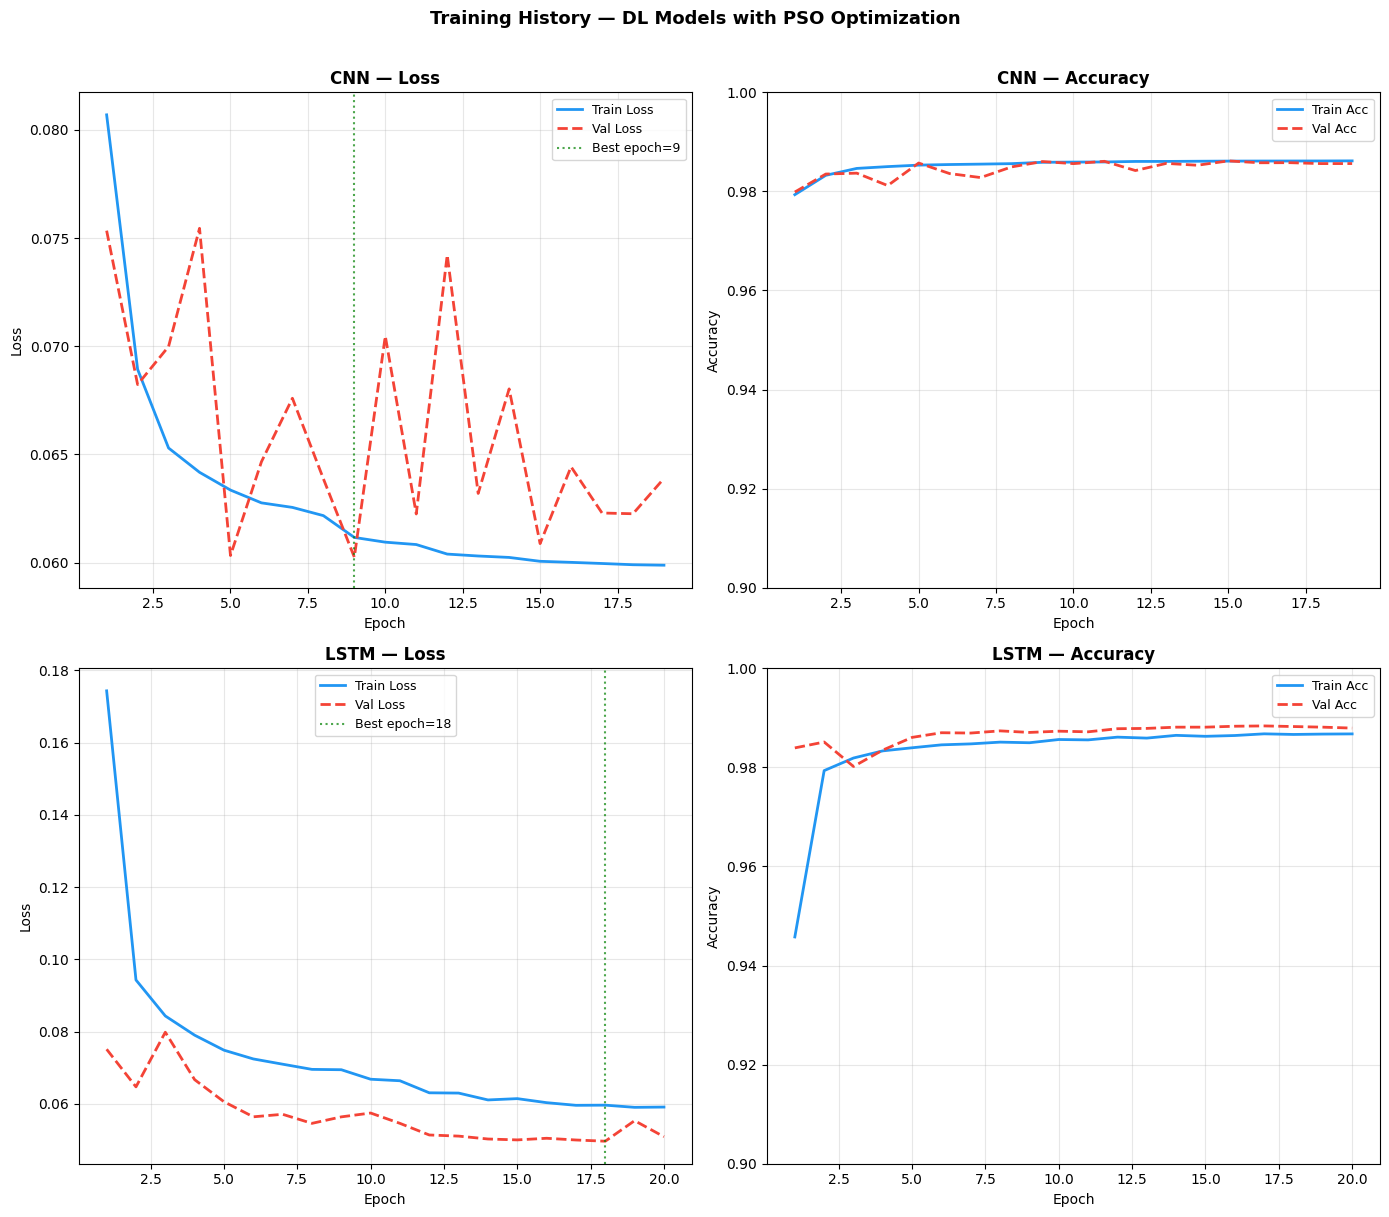

In [10]:
print('\n📊 Plotting training history...')
 
n_models = len(histories)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 6 * n_models))
if n_models == 1:
    axes = axes.reshape(1, -1)
 
for idx, (model_name, history) in enumerate(histories.items()):
    h = history.history
    epochs_range = range(1, len(h['loss']) + 1)
 
    axes[idx, 0].plot(epochs_range, h['loss'],     label='Train Loss', color='#2196F3', linewidth=2)
    axes[idx, 0].plot(epochs_range, h['val_loss'], label='Val Loss',   color='#F44336', linewidth=2, linestyle='--')
    best_ep = np.argmin(h['val_loss']) + 1
    axes[idx, 0].axvline(best_ep, color='green', linestyle=':', alpha=0.7, label=f'Best epoch={best_ep}')
    axes[idx, 0].set_title(f'{model_name} — Loss', fontweight='bold', fontsize=12)
    axes[idx, 0].set_xlabel('Epoch'); axes[idx, 0].set_ylabel('Loss')
    axes[idx, 0].legend(fontsize=9);  axes[idx, 0].grid(alpha=0.3)
 
    axes[idx, 1].plot(epochs_range, h['accuracy'],     label='Train Acc', color='#2196F3', linewidth=2)
    axes[idx, 1].plot(epochs_range, h['val_accuracy'], label='Val Acc',   color='#F44336', linewidth=2, linestyle='--')
    axes[idx, 1].set_title(f'{model_name} — Accuracy', fontweight='bold', fontsize=12)
    axes[idx, 1].set_xlabel('Epoch'); axes[idx, 1].set_ylabel('Accuracy')
    axes[idx, 1].legend(fontsize=9);  axes[idx, 1].grid(alpha=0.3)
    axes[idx, 1].set_ylim(0.9, 1.0)
 
plt.suptitle('Training History — DL Models with PSO Optimization',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
hist_path = os.path.join(BASE_MODEL_DIR, 'training_history.png')
plt.savefig(hist_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {hist_path}')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 11. Performance Comparison Charts
# ─────────────────────────────────────────────────────────────────────────────


✅ Saved → trained_models/dl_optimized/pso/metrics_comparison.png


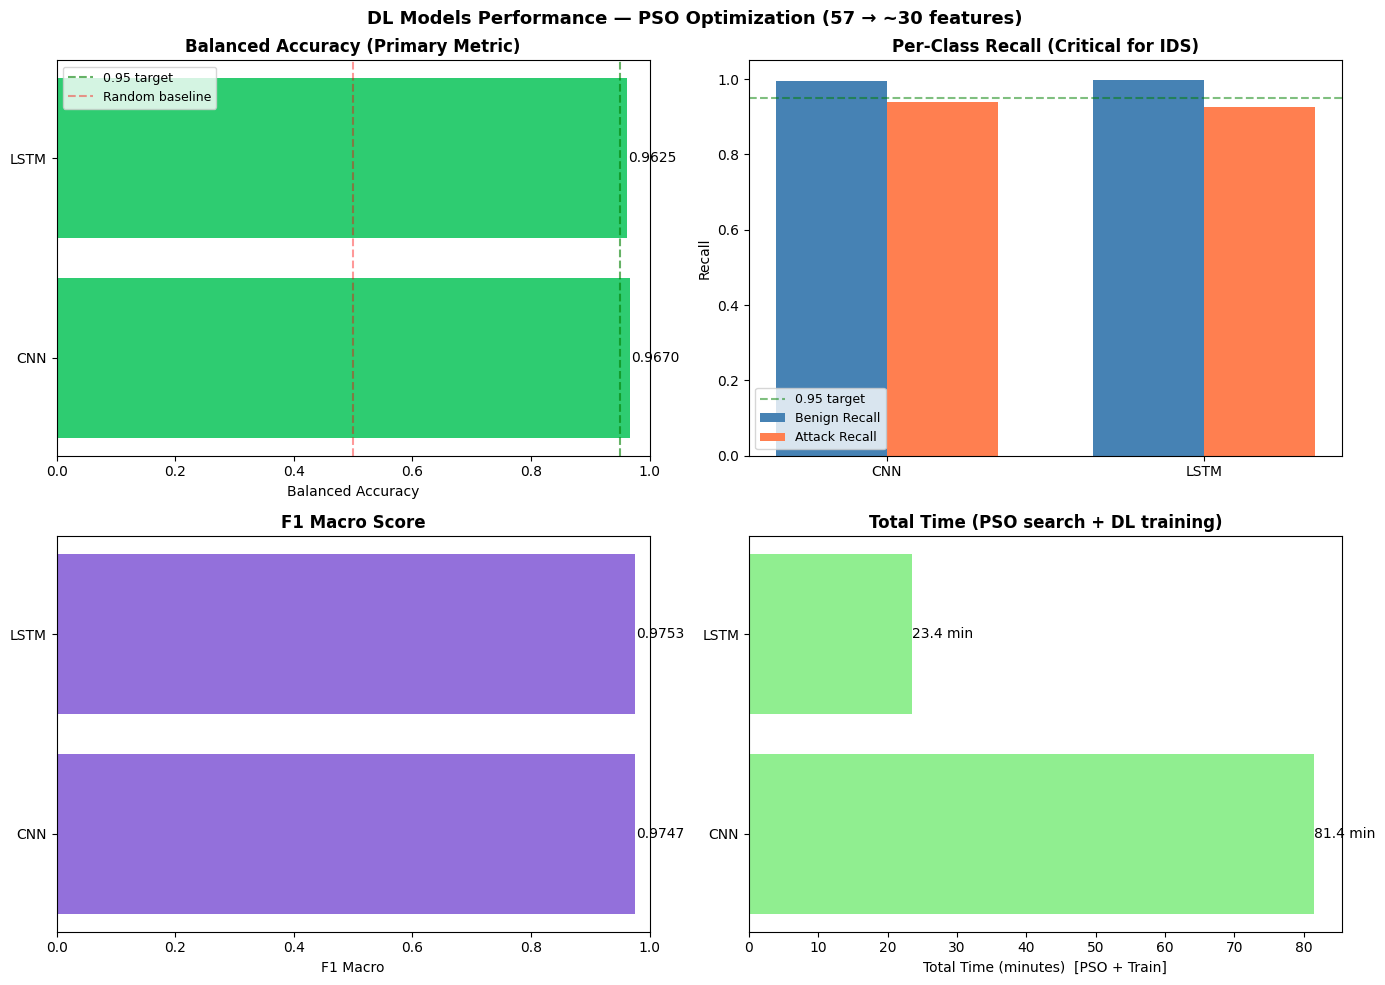

In [11]:
model_names = summary_df.index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'DL Models Performance — PSO Optimization (57 → ~{N_FEATURES_TARGET} features)',
    fontsize=13, fontweight='bold'
)
 
colors_ba = ['#2ecc71' if v >= 0.95 else '#f39c12' if v >= 0.90 else '#e74c3c'
             for v in summary_df['balanced_accuracy']]
axes[0, 0].barh(model_names, summary_df['balanced_accuracy'], color=colors_ba)
axes[0, 0].set_xlabel('Balanced Accuracy')
axes[0, 0].set_title('Balanced Accuracy (Primary Metric)', fontweight='bold')
axes[0, 0].set_xlim(0, 1)
axes[0, 0].axvline(0.95, color='green', linestyle='--', alpha=0.6, label='0.95 target')
axes[0, 0].axvline(0.5,  color='red',   linestyle='--', alpha=0.4, label='Random baseline')
for i, v in enumerate(summary_df['balanced_accuracy']):
    axes[0, 0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)
axes[0, 0].legend(fontsize=9)
 
x = np.arange(len(model_names)); width = 0.35
axes[0, 1].bar(x - width/2, summary_df['benign_recall'], width, label='Benign Recall', color='steelblue')
axes[0, 1].bar(x + width/2, summary_df['attack_recall'], width, label='Attack Recall', color='coral')
axes[0, 1].set_ylabel('Recall')
axes[0, 1].set_title('Per-Class Recall (Critical for IDS)', fontweight='bold')
axes[0, 1].set_xticks(x); axes[0, 1].set_xticklabels(model_names, fontsize=10)
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].axhline(0.95, color='green', linestyle='--', alpha=0.5, label='0.95 target')
axes[0, 1].legend(fontsize=9)
 
axes[1, 0].barh(model_names, summary_df['f1_macro'], color='mediumpurple')
axes[1, 0].set_xlabel('F1 Macro')
axes[1, 0].set_title('F1 Macro Score', fontweight='bold')
axes[1, 0].set_xlim(0, 1)
for i, v in enumerate(summary_df['f1_macro']):
    axes[1, 0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)
 
total_time = (summary_df['train_time'] + summary_df['pso_time']) / 60
axes[1, 1].barh(model_names, total_time, color='lightgreen')
axes[1, 1].set_xlabel('Total Time (minutes)  [PSO + Train]')
axes[1, 1].set_title('Total Time (PSO search + DL training)', fontweight='bold')
for i, v in enumerate(total_time):
    axes[1, 1].text(v + 0.05, i, f'{v:.1f} min', va='center', fontsize=10)
 
plt.tight_layout()
comp_path = os.path.join(BASE_MODEL_DIR, 'metrics_comparison.png')
plt.savefig(comp_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {comp_path}')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 12. Confusion Matrices
# ─────────────────────────────────────────────────────────────────────────────


✅ Saved → trained_models/dl_optimized/pso/confusion_matrices.png


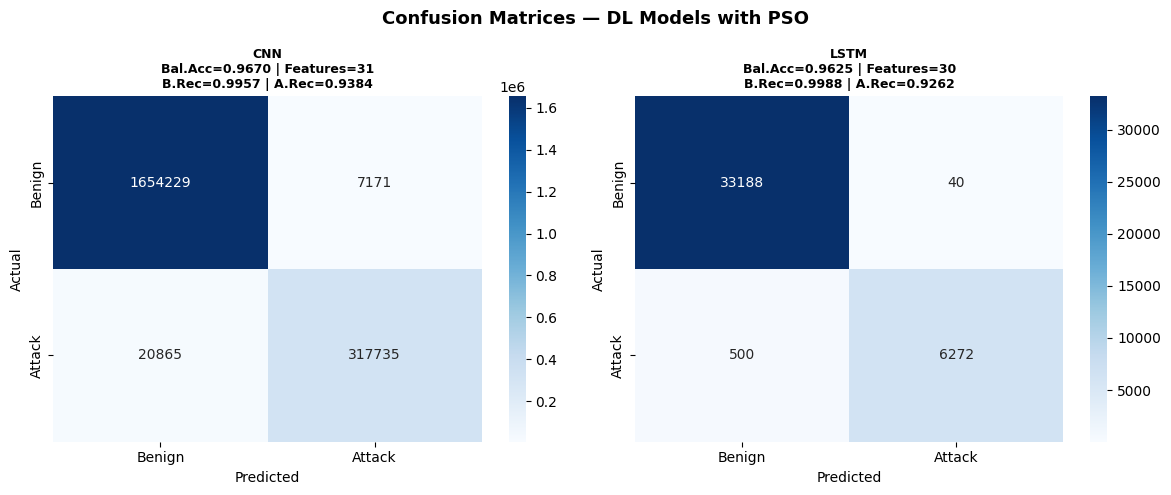

In [12]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]
 
for idx, model_name in enumerate(summary_df.index):
    r  = results[model_name]
    cm = r['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
    axes[idx].set_title(
        f'{model_name}\nBal.Acc={r["balanced_accuracy"]:.4f} | '
        f'Features={r["n_features_selected"]}\n'
        f'B.Rec={r["benign_recall"]:.4f} | A.Rec={r["attack_recall"]:.4f}',
        fontweight='bold', fontsize=9
    )
    axes[idx].set_ylabel('Actual'); axes[idx].set_xlabel('Predicted')
 
plt.suptitle('Confusion Matrices — DL Models with PSO', fontsize=13, fontweight='bold')
plt.tight_layout()
cm_path = os.path.join(BASE_MODEL_DIR, 'confusion_matrices.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {cm_path}')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 13. PSO Convergence Analysis  
# ─────────────────────────────────────────────────────────────────────────────


✅ Saved → trained_models/dl_optimized/pso/pso_convergence.png


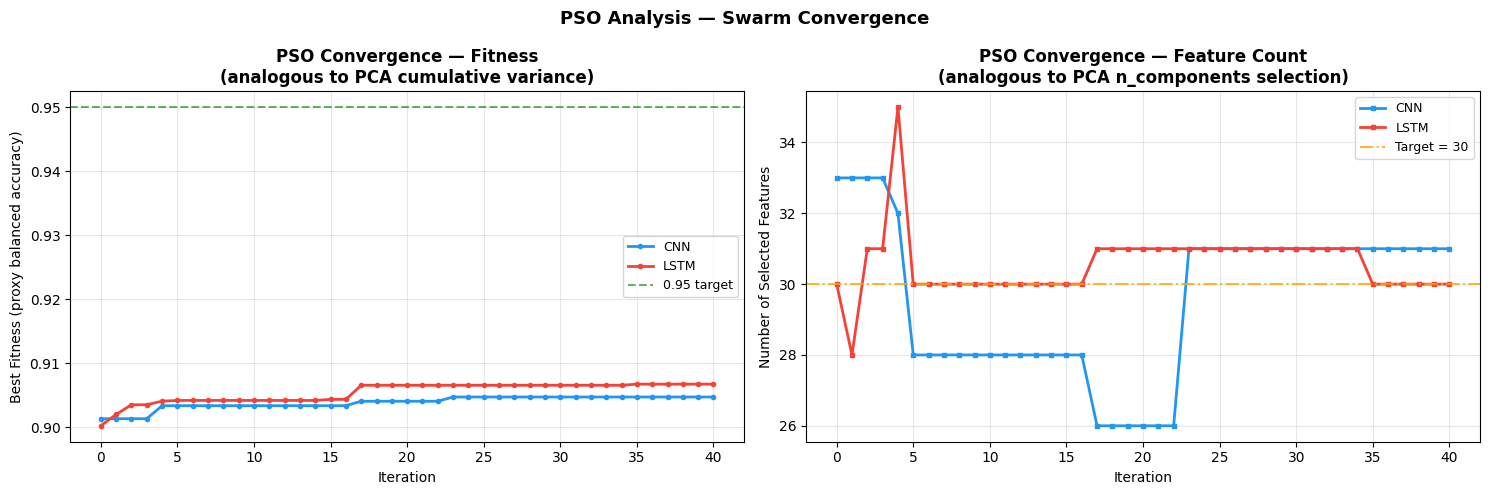

In [13]:

 
n_models = len(pso_fit_histories)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
 
colors_model = {'CNN': '#2196F3', 'LSTM': '#F44336'}
 
for model_name, (fit_hist, nsel_hist) in pso_fit_histories.items():
    c = colors_model.get(model_name, 'gray')
    axes[0].plot(range(len(fit_hist)), fit_hist, label=model_name,
                 color=c, linewidth=2, marker='o', markersize=3)
    axes[1].plot(range(len(nsel_hist)), nsel_hist, label=model_name,
                 color=c, linewidth=2, marker='s', markersize=3)
 
axes[0].axhline(y=0.95, color='g', linestyle='--', label='0.95 target', alpha=0.6)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Best Fitness (proxy balanced accuracy)')
axes[0].set_title('PSO Convergence — Fitness\n(analogous to PCA cumulative variance)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
 
axes[1].axhline(y=N_FEATURES_TARGET, color='orange', linestyle='-.', alpha=0.8,
                label=f'Target = {N_FEATURES_TARGET}')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Number of Selected Features')
axes[1].set_title('PSO Convergence — Feature Count\n(analogous to PCA n_components selection)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
 
plt.suptitle('PSO Analysis — Swarm Convergence', fontsize=13, fontweight='bold')
plt.tight_layout()
pso_path = os.path.join(BASE_MODEL_DIR, 'pso_convergence.png')
plt.savefig(pso_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {pso_path}')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 14. Feature Mask Visualisation
# ─────────────────────────────────────────────────────────────────────────────


✅ Saved → trained_models/dl_optimized/pso/pso_feature_masks.png


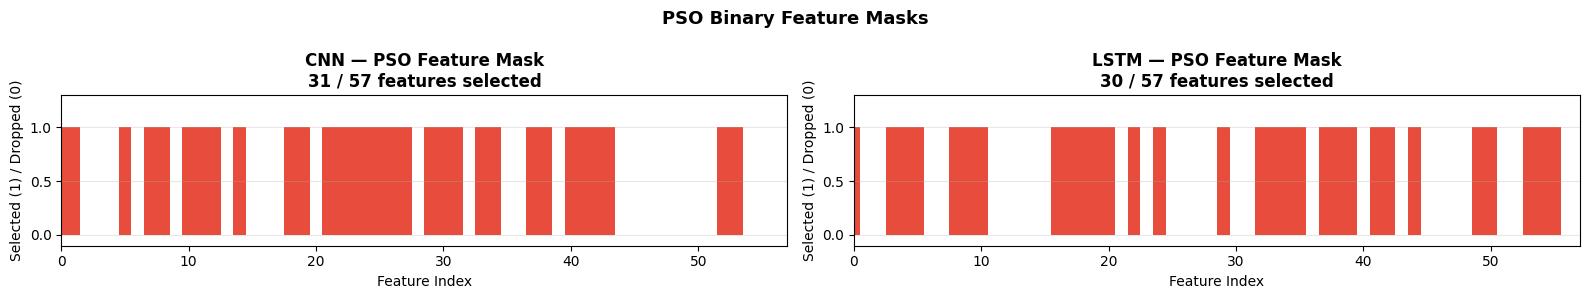

In [14]:
fig, axes = plt.subplots(1, len(pso_masks), figsize=(8 * len(pso_masks), 3))
if len(pso_masks) == 1:
    axes = [axes]
 
for ax, (model_name, mask) in zip(axes, pso_masks.items()):
    ax.bar(range(N_FEATURES), mask, color=['#e74c3c' if m else '#bdc3c7' for m in mask], width=1.0)
    ax.set_xlabel('Feature Index')
    ax.set_ylabel('Selected (1) / Dropped (0)')
    ax.set_title(f'{model_name} — PSO Feature Mask\n'
                 f'{int(mask.sum())} / {N_FEATURES} features selected',
                 fontweight='bold')
    ax.set_xlim(0, N_FEATURES)
    ax.set_ylim(-0.1, 1.3)
    ax.grid(axis='y', alpha=0.3)
 
plt.suptitle('PSO Binary Feature Masks', fontsize=13, fontweight='bold')
plt.tight_layout()
mask_path = os.path.join(BASE_MODEL_DIR, 'pso_feature_masks.png')
plt.savefig(mask_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {mask_path}')
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 15. Final Summary
# ─────────────────────────────────────────────────────────────────────────────


In [15]:
print('\n' + '=' * 80)
print('🎉 TRAINING COMPLETE — PSO OPTIMIZATION')
print('=' * 80)
 
print(f'\n📊 Models Ranked by Balanced Accuracy:')
print(f'   {"Rank":<4} {"Model":<6} {"Bal.Acc":>8} '
      f'{"B.Recall":>9} {"A.Recall":>9} {"F1-Mac":>7} '
      f'{"#Feat":>6} {"PSO":>6} {"Train":>8}')
print('   ' + '─' * 72)
for rank, (model_name, row) in enumerate(summary_df.iterrows(), 1):
    print(f'   {rank:<4} {model_name:<6} '
          f'{row["balanced_accuracy"]:>8.4f} '
          f'{row["benign_recall"]:>9.4f} '
          f'{row["attack_recall"]:>9.4f} '
          f'{row["f1_macro"]:>7.4f} '
          f'{int(row["n_features_selected"]):>6} '
          f'{row["pso_time"]/60:>5.1f}m '
          f'{row["train_time"]/60:>7.1f}m')
 
best = summary_df.index[0]
print(f'\n🏆 Best model: {best}')
print(f'   Balanced Accuracy  : {summary_df.loc[best, "balanced_accuracy"]:.4f}')
print(f'   Benign Recall      : {summary_df.loc[best, "benign_recall"]:.4f}')
print(f'   Attack Recall      : {summary_df.loc[best, "attack_recall"]:.4f}')
print(f'   Features selected  : {int(summary_df.loc[best, "n_features_selected"])} / {N_FEATURES}')
print(f'   PSO best fitness   : {summary_df.loc[best, "pso_best_fitness"]:.4f}')
 
print(f'\n📁 All models saved to: {BASE_MODEL_DIR}')
for model_name in MODEL_BUILDERS:
    d = os.path.join(BASE_MODEL_DIR, model_name.lower())
    print(f'   {d}/')
    print(f'     best_model.keras   ← best val_loss checkpoint')
    print(f'     final_model.keras  ← end-of-training weights')
    print(f'     scaler.pkl         ← StandardScaler (fit on train)')
    print(f'     pso_mask.pkl       ← binary feature mask  [replaces pca.pkl]')
    print(f'     history.pkl')
    print(f'     metadata.pkl')
 
print('\n💡 PCA vs PSO — key difference:')
print('   PCA : linear, deterministic, unsupervised → new axes, not interpretable')
print('   PSO : metaheuristic, stochastic, supervised → original features kept')
print('   PSO analogy: convergence curve ≈ PCA cumulative variance plot')
print(f'\n   PSO: 57 features → ~{N_FEATURES_TARGET} selected via swarm intelligence.')
print(f'   PSO particles: {PSO_N_PARTICLES} | Iterations: {PSO_ITERATIONS}')
print('   Fitness function: balanced_accuracy (LogisticRegression proxy) - sparsity penalty')



🎉 TRAINING COMPLETE — PSO OPTIMIZATION

📊 Models Ranked by Balanced Accuracy:
   Rank Model   Bal.Acc  B.Recall  A.Recall  F1-Mac  #Feat    PSO    Train
   ────────────────────────────────────────────────────────────────────────
   1    CNN      0.9670    0.9957    0.9384  0.9747     31  11.4m    70.0m
   2    LSTM     0.9625    0.9988    0.9262  0.9753     30  11.4m    12.0m

🏆 Best model: CNN
   Balanced Accuracy  : 0.9670
   Benign Recall      : 0.9957
   Attack Recall      : 0.9384
   Features selected  : 31 / 57
   PSO best fitness   : 0.9047

📁 All models saved to: trained_models/dl_optimized/pso/
   trained_models/dl_optimized/pso/cnn/
     best_model.keras   ← best val_loss checkpoint
     final_model.keras  ← end-of-training weights
     scaler.pkl         ← StandardScaler (fit on train)
     pso_mask.pkl       ← binary feature mask  [replaces pca.pkl]
     history.pkl
     metadata.pkl
   trained_models/dl_optimized/pso/lstm/
     best_model.keras   ← best val_loss checkpoin